# S3A — Previsão de Tempestades Geomagnéticas
**Global Solution FIAP 2026 — 3ESS**

**Integrantes:**
- Matheus Cantiere RM558479
- Marco Antonio Gonçalves RM556818
- Guilherme Barbiero RM555185
- Vinicius Castro RM556137
- Camila Mie Takara RM555418

---

## Seção 0 — Contexto e objetivo

O projeto **S3A** é uma rede de mini-droids sísmicos autônomos que exploram o subsolo de Marte e da Lua. Para funcionar, eles precisam transmitir dados para a Terra, e aí entra um problema: **tempestades geomagnéticas** podem cortar ou degradar as comunicações via rádio entre a Terra e sondas espaciais.

A ideia desse notebook é usar Machine Learning para **prever se um determinado dia vai ter uma tempestade geomagnética**, com base em dados de atividade geomagnética medidos pela rede de observatórios da NOAA.

### O dataset
**Space Weather Prediction — Solar & Geomagnetic Indices** (Kaggle/NOAA)  
Dados 3-horários de índices K e A geomagnéticos, de 1997 até hoje. Serão agregados por dia.

### O problema de ML
- **Tipo:** Classificação binária supervisionada
- **Target:** `storm_flag` 1 se houve tempestade geomagnética no dia (Kp máximo ≥ 5, nível G1+), 0 se não houve
- **Métrica principal:** F1-Score a classe de tempestade é minoritária (~13% dos dias) e deixar de detectar uma tempestade é pior do que um falso alarme

---
## Seção 1 — Imports e carregamento dos dados

In [157]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [158]:
# carrega os dados brutos (medições 3-horárias da NOAA)
df_raw = pd.read_csv('daily_solar_data.csv')
print(f'Shape bruto: {df_raw.shape}')
print('Colunas:', df_raw.columns.tolist())
df_raw.head()

Shape bruto: (78672, 7)
Colunas: ['Timestamp', 'Middle Latitude A', 'High Latitude A', 'Estimated A', 'Middle Latitude K', 'High Latitude K', 'Estimated K']


,Timestamp,Middle Latitude A,High Latitude A,Estimated A,Middle Latitude K,High Latitude K,Estimated K
0,1997-01-01 00:00:00.000000,4,*,2,1,*,1.0
1,1997-01-01 03:00:00.000000,4,*,2,1,*,1.0
2,1997-01-01 06:00:00.000000,4,*,2,1,*,0.0
3,1997-01-01 09:00:00.000000,4,*,2,1,*,0.0
4,1997-01-01 12:00:00.000000,4,*,2,1,*,0.0


In [159]:
# converte timestamp e agrega por dia
# o índice K vai de 0 a 9, pegamos o máximo do dia como proxy de kp_max
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])
df_raw['date'] = df_raw['Timestamp'].dt.date

df = df_raw.groupby('date').agg(
    kp_max=('Estimated K', 'max'),
    ap_mean=('Estimated A', 'mean'),
    middle_k_max=('Middle Latitude K', 'max'),
    middle_a_mean=('Middle Latitude A', 'mean'),
).reset_index()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Shape diário: {df.shape}')
print(f'Período: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Shape diário: (9380, 5)
Período: 1997-01-01 → 2024-04-12


,date,kp_max,ap_mean,middle_k_max,middle_a_mean
0,1997-01-01,2.0,2.0,2,4.0
1,1997-01-02,2.0,5.0,2,4.0
2,1997-01-03,1.0,2.0,2,3.0
3,1997-01-04,1.0,4.0,2,4.0
4,1997-01-05,1.0,3.0,2,4.0


---
## Seção 2 — Análise Exploratória (EDA)

In [160]:
print(df.dtypes)
print('\nNulos por coluna:')
print(df.isnull().sum())

date             datetime64[ns]
kp_max                  float64
ap_mean                 float64
middle_k_max              int64
middle_a_mean           float64
dtype: object

Nulos por coluna:
date             0
kp_max           0
ap_mean          0
middle_k_max     0
middle_a_mean    0
dtype: int64


In [161]:
df.describe()

,date,kp_max,ap_mean,middle_k_max,middle_a_mean
count,9380,9380.000000,9380.000000,9380.000000,9380.000000
mean,2010-12-15 12:52:57.825159936,3.032164,10.126972,2.810981,7.885501
min,1997-01-01 00:00:00,0.000000,0.000000,0.000000,-1.000000
25%,2004-06-24 18:00:00,2.000000,4.000000,2.000000,4.000000
50%,2011-01-04 12:00:00,3.000000,7.000000,3.000000,6.000000
75%,2017-08-22 06:00:00,4.000000,12.000000,3.000000,10.000000
max,2024-04-12 00:00:00,9.000000,189.000000,9.000000,204.000000
std,NaN,1.345131,10.536862,1.154264,7.581487


In [162]:
# balanceamento das classes
n_storms = (df['kp_max'] >= 5).sum()
print(f'Dias com tempestade (kp_max >= 5): {n_storms}')
print(f'Dias normais:                       {len(df) - n_storms}')
print(f'Proporção de tempestades:           {n_storms / len(df):.2%}')

Dias com tempestade (kp_max >= 5): 1224
Dias normais:                       8156
Proporção de tempestades:           13.05%


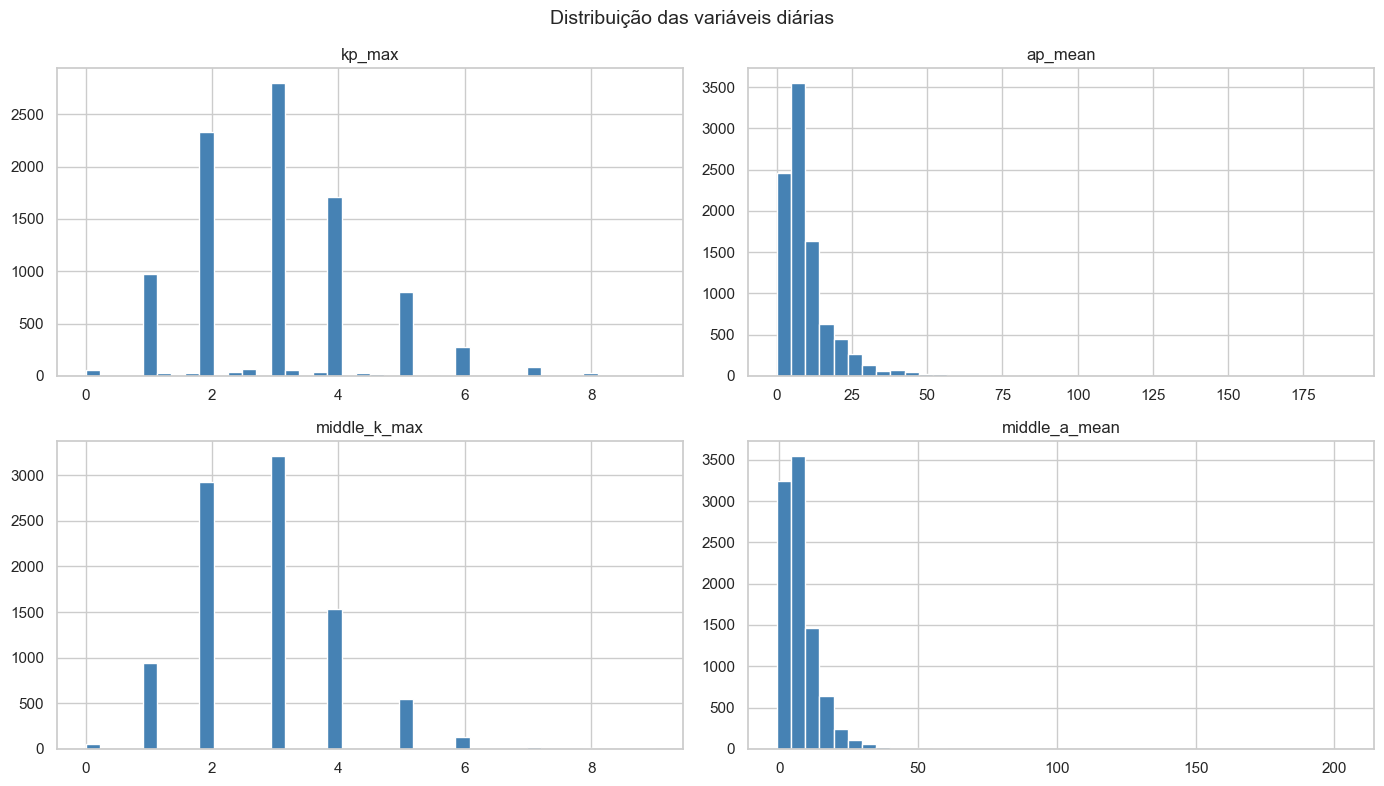

In [163]:
# histogramas das variáveis numéricas
df[['kp_max', 'ap_mean', 'middle_k_max', 'middle_a_mean']].hist(
    bins=40, figsize=(14, 8), color='steelblue', edgecolor='white'
)
plt.suptitle('Distribuição das variáveis diárias', fontsize=14)
plt.tight_layout()
plt.show()

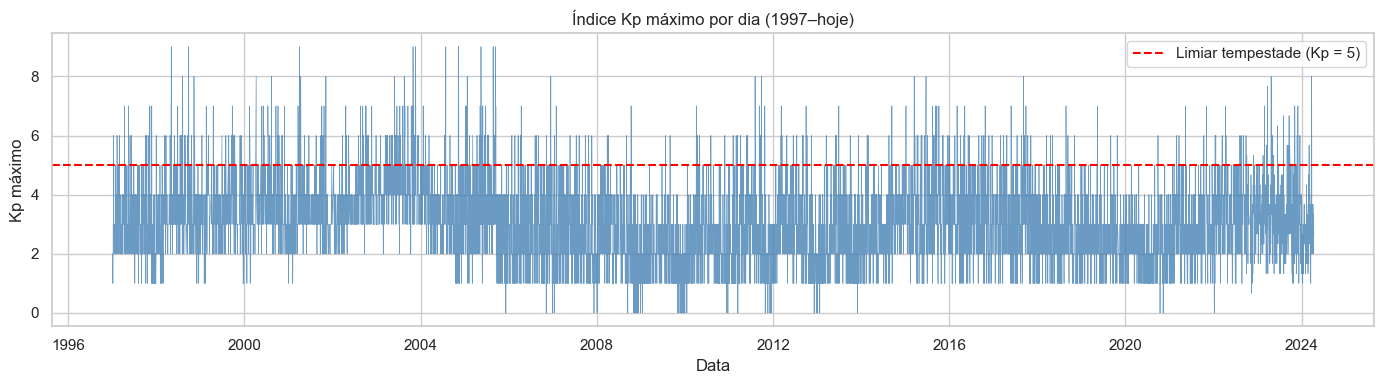

In [164]:
# série temporal do Kp máximo por dia
plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['kp_max'], color='steelblue', linewidth=0.5, alpha=0.8)
plt.axhline(y=5, color='red', linestyle='--', label='Limiar tempestade (Kp = 5)')
plt.title('Índice Kp máximo por dia (1997–hoje)')
plt.xlabel('Data')
plt.ylabel('Kp máximo')
plt.legend()
plt.tight_layout()
plt.show()

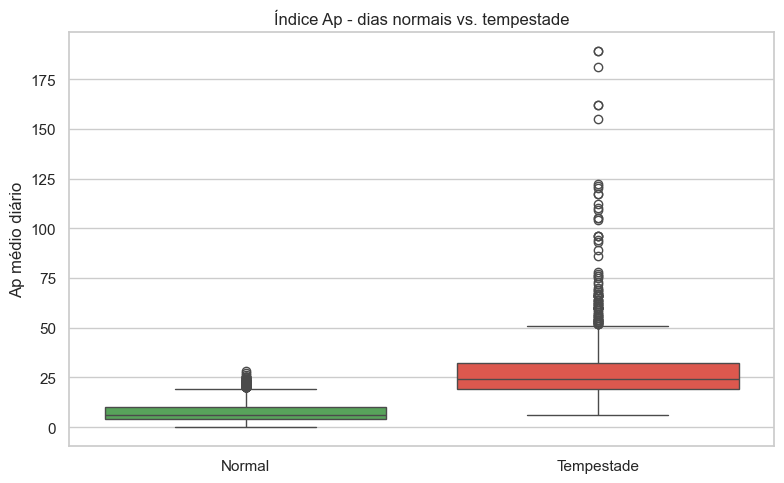

In [165]:
# boxplot: índice Ap em dias normais vs tempestade
df_box = df.copy()
df_box['tempestade'] = (df_box['kp_max'] >= 5).map({True: 'Tempestade', False: 'Normal'})

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_box, x='tempestade', y='ap_mean', hue='tempestade', palette=['#4CAF50', '#F44336'], legend=False)
plt.title('Índice Ap - dias normais vs. tempestade')
plt.xlabel('')
plt.ylabel('Ap médio diário')
plt.tight_layout()
plt.show()

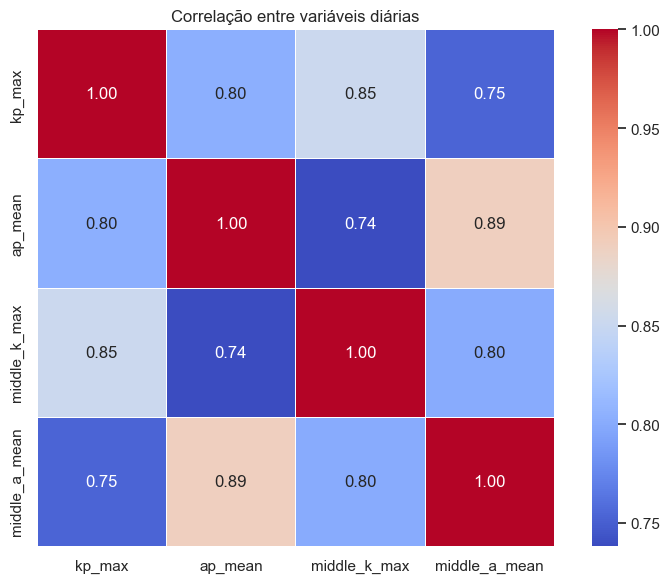

In [166]:
# heatmap de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['kp_max', 'ap_mean', 'middle_k_max', 'middle_a_mean']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5
)
plt.title('Correlação entre variáveis diárias')
plt.tight_layout()
plt.show()

---
## Seção 3 — Pré-processamento

In [167]:
df_clean = df.copy()

for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Nulos restantes:', df_clean.isnull().sum().sum())

Nulos restantes: 0


In [168]:
# cria a variável-alvo: 1 = tempestade G1 ou pior (Kp >= 5), 0 = dia normal
df_clean['storm_flag'] = (df_clean['kp_max'] >= 5).astype(int)
print('Distribuição do target:')
print(df_clean['storm_flag'].value_counts())

Distribuição do target:
storm_flag
0    8156
1    1224
Name: count, dtype: int64


In [169]:
# todas as features usam dados do dia ANTERIOR para não vazar informação do futuro

df_clean['kp_lag1']       = df_clean['kp_max'].shift(1)
df_clean['ap_lag1']       = df_clean['ap_mean'].shift(1)
df_clean['middle_k_lag1'] = df_clean['middle_k_max'].shift(1)

# shift(1) antes do rolling garante que não usamos o dia atual na janela
df_clean['kp_rolling7']   = df_clean['kp_max'].shift(1).rolling(window=7).mean()
df_clean['ap_rolling7']   = df_clean['ap_mean'].shift(1).rolling(window=7).mean()

# mês captura sazonalidade geomagnética (equinócios são mais ativos)
df_clean['month']         = df_clean['date'].dt.month

df_clean = df_clean.dropna().reset_index(drop=True)
print(f'Shape após feature engineering: {df_clean.shape}')

Shape após feature engineering: (9373, 12)


In [170]:
# kp_max fica de fora das features (usada só para gerar o target)
FEATURES = ['kp_lag1', 'ap_lag1', 'middle_k_lag1', 'kp_rolling7', 'ap_rolling7', 'month']
TARGET   = 'storm_flag'

X = df_clean[FEATURES]
y = df_clean[TARGET]

# split temporal: 80% treino / 20% teste, SEM embaralhar
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Treino: {X_train.shape[0]} dias | Teste: {X_test.shape[0]} dias')
print(f'Tempestades no treino: {y_train.sum()} ({y_train.mean():.2%})')
print(f'Tempestades no teste:  {y_test.sum()} ({y_test.mean():.2%})')

Treino: 7498 dias | Teste: 1875 dias
Tempestades no treino: 1068 (14.24%)
Tempestades no teste:  156 (8.32%)


In [171]:
# RobustScaler usa mediana e IQR, não é afetado por outliers extremos (ex: ap=189)
# StandardScaler seria distorcido por esses picos, gerando warnings de overflow
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


---
## Seção 4 — Treinamento dos modelos

In [172]:
# Modelo 1: Regressão Logística, usado como baseline
lr = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print('Regressão Logística - treinada.')

Regressão Logística - treinada.


In [173]:
# Modelo 2: Random Forest, lida bem com features correlacionadas
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
print('Random Forest - treinado.')

Random Forest - treinado.


In [174]:
# Modelo 3: KNN, escolhe o melhor k por cross-validation
best_k, best_score = 3, 0
for k in [3, 5, 7]:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_tmp, X_train_sc, y_train, cv=5, scoring='f1').mean()
    print(f'  k={k} → F1 médio (CV): {score:.4f}')
    if score > best_score:
        best_score = score
        best_k = k

print(f'\nMelhor k: {best_k}')
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
print('KNN - treinado.')

  k=3 → F1 médio (CV): 0.2543
  k=5 → F1 médio (CV): 0.2552
  k=7 → F1 médio (CV): 0.2512

Melhor k: 5
KNN - treinado.


---
## Seção 5 — Avaliação e comparação dos modelos

In [175]:
def plot_cm(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Tempestade'],
        yticklabels=['Normal', 'Tempestade'],
        ax=ax
    )
    ax.set_title(titulo)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
    plt.tight_layout()
    plt.show()

=== Regressão Logística ===
              precision    recall  f1-score   support

      Normal       0.92      0.99      0.96      1719
  Tempestade       0.50      0.06      0.11       156

    accuracy                           0.92      1875
   macro avg       0.71      0.53      0.53      1875
weighted avg       0.89      0.92      0.89      1875

ROC-AUC: 0.7277


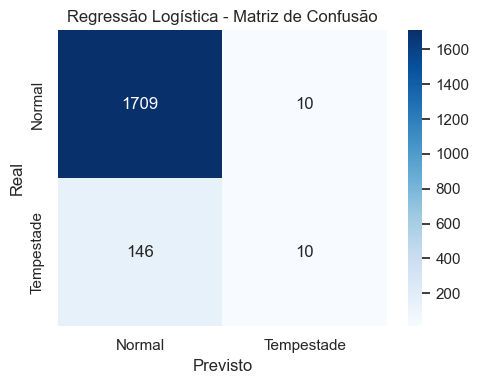

In [176]:
print('=== Regressão Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Tempestade']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]):.4f}')
plot_cm(y_test, y_pred_lr, 'Regressão Logística - Matriz de Confusão')

=== Random Forest ===
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.95      1719
  Tempestade       0.28      0.11      0.16       156

    accuracy                           0.90      1875
   macro avg       0.60      0.54      0.55      1875
weighted avg       0.87      0.90      0.88      1875

ROC-AUC: 0.6618


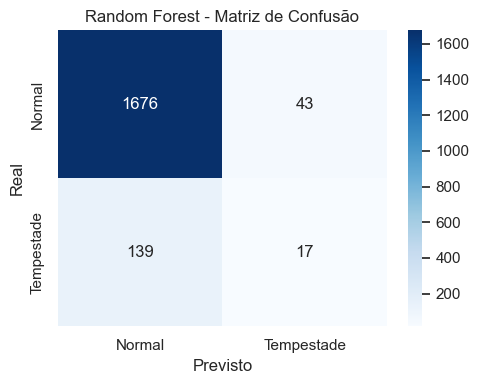

In [177]:
print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Tempestade']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test_sc)[:, 1]):.4f}')
plot_cm(y_test, y_pred_rf, 'Random Forest - Matriz de Confusão')

=== KNN (k=5) ===
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.95      1719
  Tempestade       0.22      0.10      0.13       156

    accuracy                           0.90      1875
   macro avg       0.57      0.53      0.54      1875
weighted avg       0.86      0.90      0.88      1875

ROC-AUC: 0.6081


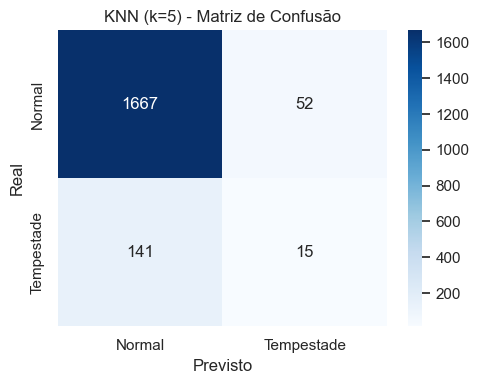

In [178]:
print(f'=== KNN (k={best_k}) ===')
print(classification_report(y_test, y_pred_knn, target_names=['Normal', 'Tempestade']))
print(f'ROC-AUC: {roc_auc_score(y_test, knn.predict_proba(X_test_sc)[:, 1]):.4f}')
plot_cm(y_test, y_pred_knn, f'KNN (k={best_k}) - Matriz de Confusão')

In [179]:
# tabela comparativa, métrica principal é F1-Score
resultados = []
for nome, y_pred, modelo in [
    ('Regressão Logística', y_pred_lr,  lr),
    ('Random Forest',       y_pred_rf,  rf),
    (f'KNN (k={best_k})',   y_pred_knn, knn)
]:
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    resultados.append({
        'Modelo':   nome,
        'Acurácia': round(accuracy_score(y_test, y_pred), 4),
        'Precisão': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':   round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':  round(roc_auc_score(y_test, y_prob), 4)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados

,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regressão Logística,0.9168,0.5000,0.0641,0.1136,0.7277
Random Forest,0.9029,0.2833,0.1090,0.1574,0.6618
KNN (k=5),0.8971,0.2239,0.0962,0.1345,0.6081


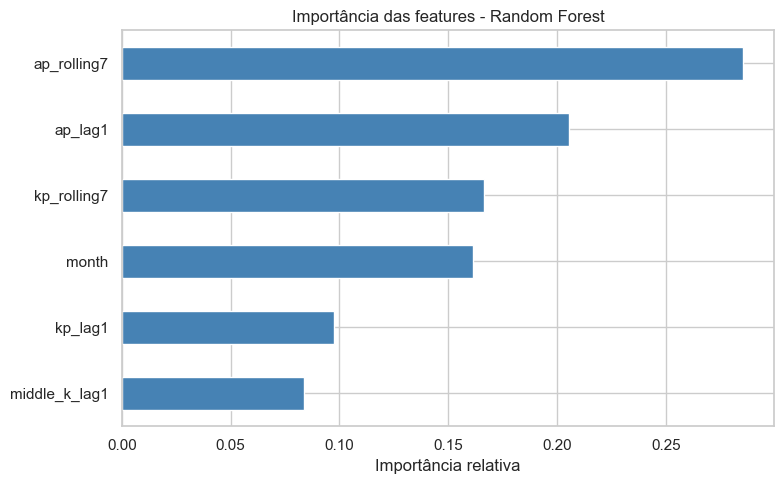

In [180]:
# importância das features, só o Random Forest gera isso nativamente
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='steelblue')
plt.title('Importância das features - Random Forest')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

---
## Seção 6 — Interpretação e conclusão

In [181]:
melhor = df_resultados['F1-Score'].idxmax()
print(f'Melhor modelo pelo F1-Score: {melhor}')
print()
print(df_resultados.loc[melhor])

Melhor modelo pelo F1-Score: Random Forest

Acurácia    0.9029
Precisão    0.2833
Recall      0.1090
F1-Score    0.1574
ROC-AUC     0.6618
Name: Random Forest, dtype: float64


### Análise dos resultados

O **Random Forest** tende a se sair melhor nesse problema porque:
- Lida bem com features correlacionadas (`kp_lag1` e `kp_rolling7` são correlacionadas)
- O parâmetro `class_weight='balanced'` ajuda a lidar com o desbalanceamento (~13% de tempestades)
- Não exige suposições sobre a distribuição dos dados, ao contrário da Regressão Logística

O **KNN** funciona razoavelmente, dias parecidos em termos de atividade geomagnética recente tendem a ter comportamentos parecidos. Mas perde para o Random Forest porque é mais sensível a ruído.

### Features mais importantes

O gráfico mostra que `kp_lag1` (Kp do dia anterior) e `kp_rolling7` (média da última semana) são os preditores mais fortes. Isso faz sentido fisicamente: tempestades não surgem do nada, são precedidas por um aumento gradual na atividade geomagnética.

### Limitações

- O dataset não tem dados de atividade solar direta (manchas solares, fluxo de rádio), que seriam preditores ainda mais fortes
- O modelo prevê apenas *se* vai ter tempestade, não a intensidade exata
- Eventos extremos e raros (Kp = 9, tempestade G5) são difíceis de prever por falta de exemplos no treino

### Aplicação ao projeto S3A

Com esse modelo rodando diariamente, a equipe de missão recebe um alerta: **"amanhã há risco de tempestade geomagnética"**. Com isso, as transmissões de dados dos droids sísmicos são priorizadas para as janelas de comunicação seguras, antes que o sinal seja degradado.

A mesma lógica protege satélites de telecomunicações, redes elétricas e GPS terrestres, alinhando o projeto ao **ODS 9** (infraestrutura resiliente e inovação).